In [104]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np 

In [105]:
df = pd.read_csv("height-weight.csv")

In [106]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'height')

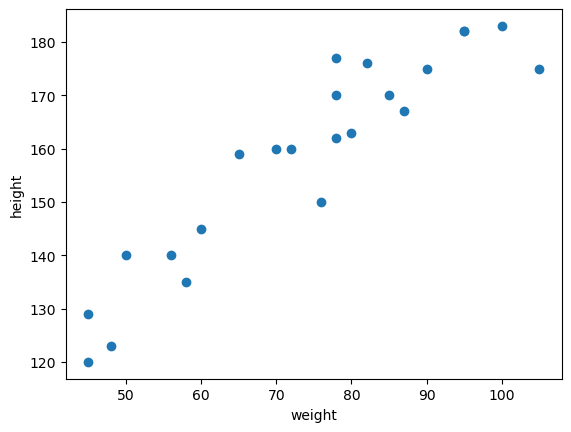

In [107]:
plt.scatter(x="Weight",y="Height",data=df)
plt.xlabel("weight")
plt.ylabel("height")

In [108]:
# problem statement --> i want to predict height based on weight

In [109]:
x = df[["Weight"]]
y = df["Height"]

In [110]:
x

,Weight
0,45
1,58
2,48
3,60
4,70
5,78
6,80
7,90
8,95
9,78


In [111]:
y

0     120
1     135
2     123
3     145
4     160
5     162
6     163
7     175
8     182
9     170
10    176
11    182
12    175
13    183
14    170
15    177
16    140
17    159
18    150
19    167
20    129
21    140
22    160
Name: Height, dtype: int64

In [112]:
from sklearn.model_selection import train_test_split

In [113]:
# train test split
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.20,random_state=1)

In [114]:
# scaling --> standardization -> we cannot apply fit and tranfrom on test data then it must be data leakage

In [115]:
from sklearn.preprocessing import StandardScaler

In [116]:
scaler = StandardScaler()

In [117]:
scaler  # scaling should be done after train test split 
# target varible cannot be scalled 
# avoid scaling categorical features 

StandardScaler()

In [118]:
x_train = scaler.fit_transform(x_train)



In [119]:
x_test = scaler.transform(x_test)

In [120]:
x_train

array([[-1.4611864 ],
       [ 0.44730196],
       [-0.26838118],
       [-1.58046693],
       [ 0.08946039],
       [ 0.32802144],
       [ 0.92442405],
       [-0.98406431],
       [ 0.62622274],
       [-1.75938771],
       [ 0.20874091],
       [-0.14910065],
       [-1.10334484],
       [ 0.20874091],
       [ 1.22262536],
       [ 1.81902797],
       [ 1.22262536],
       [ 0.20874091]])

In [121]:
x_test

array([[-1.75938771],
       [-0.56658248],
       [-0.86478379],
       [ 1.52082666],
       [ 0.74550327]])

In [122]:
# model training 
from sklearn.linear_model import LinearRegression
# linear reg parameters 
# fit_intercept --> best fit line has intercept 
# copy_x --> copy the original x_train to build the model it iwll not modify the original data
# n_jobs --> use all the procesors 
# positive --> when set to true , coefficient will be true 

In [123]:
lr = LinearRegression()
lr

LinearRegression()

In [124]:
lr.fit(x_train,y_train)

LinearRegression()

In [125]:
lr.coef_ # slope of the model 

array([17.73635106])

In [126]:
lr.intercept_  # intercept of the model 

np.float64(158.88888888888889)

In [127]:
lr.predict(x_train)

array([132.97277388, 166.82239348, 154.12878613, 130.85717266,
       160.47558981, 164.70679226, 175.28479838, 141.43517878,
       169.99579532, 127.68377082, 162.59119103, 156.24438736,
       139.31957756, 162.59119103, 180.57380145, 191.15180757,
       180.57380145, 162.59119103])

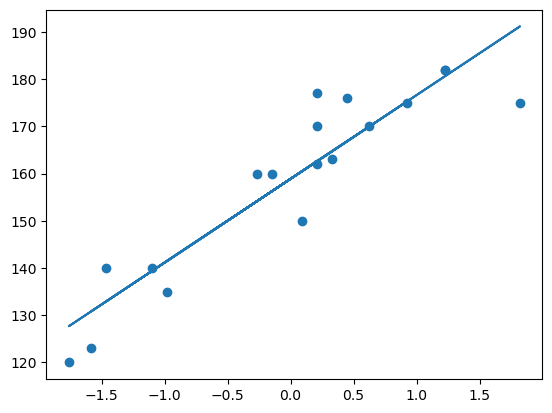

In [128]:
plt.scatter(x_train,y_train)
plt.plot(x_train,lr.predict(x_train))  # this is for train data

In [129]:
y_predict = lr.predict(x_test)

In [130]:
from sklearn.metrics import mean_squared_error , r2_score,mean_absolute_error

In [131]:
mean_squared_error(y_test,y_predict)

28.276946048811993

In [ ]:
r2_score(y_test,y_predict)    # ssr/tss

0.9171832648523548